Text preprocessing

For this exercises we will be using NLTK and spaCy

The corpus will be the Lewis Carrol books:

    Alice’s Adventures in Wonderland

    THROUGH THE LOOKING-GLASS And What Alice Found There

    A Tangled Tale


1. Using requests to access the contents online, create a function load_texts().This function should recive a list of urls, load them, clean non-words using regular expressions and append the cleaned text to the corpus that will be returned.

2. Print the first 200 characteres of each text.

Are there parts of the text that are not relevant to the analysis? If so, you need to remove them.

hint: You can use slicing to start and stop the text where you need (ignoring autoral credits in the begining and end) looking for the following phrases:

‘ START’
‘ END’

3. Tokenize the text and print the first 150 tokens of each book

4. Remove stopwords using NLTK. Check that they were removed using count() and looking for some of the stop words like: ‘i’, ‘me’, ‘my’, ‘myself’, ‘we’, ‘our’, ‘ours’, ‘ourselves’, etc.

5. Using PorterStemmer(), print the first 50 stemmed tokens

6. Using spaCy pre-trained model ‘en_core_web_sm’ to load and print the first 50 lemmatized tokens. Hint: in spaCy the lemmatized token can be accessed as attribute.

7. Analyse the difference between the stemmed and lemmatized tokens. What is different and why?

8. Using NLTK, identify POS tags od each text.

9. Using NLTK identify all the entities of each text


Analysing the text

1. Using wordcloud and matplotlib, display a word cloud of each book.

The output will look like this (maybe not exactly):



word-cloud

2. Use BoW method to check the five most frequent words in all the books

hint: What will be the best text from the preprocess step? (raw text, stemmed, lemmarized, etc)?

3. Print the BoW and identify the numbers: What is the document number? What is the index and what is how many times the word was found?

4. Display a pie plot of the 5 most frequent words in the text. Add the word and its frequence as labels.

5. Analyse the outputs: Are those words informative? Are they insightful or expected?



image-3

Solving the frequency problem using TF-IDF

When we create a BoW out from some text, all the words are treated equaly as importants. Like “Alice” or “say” in a fantasy book about Alice. We expected those words to be repeated all over the book, making them not so informative to us.

The solution for this problem would be to consider the frequency relative to the corpus. In this case, if there is a word in a document that doesn’t appears much in the other documents, it is likely meaningful and should be considered more important. And the same way in the oposite: A word that is repeated a lot in all the documents will be considered less important.

That’s the perfect situation to use TF-IDF (Term Frequency-Inverse Document Frequency)

1. Create another BoW, now using TF-IDF as vectorizer.

hint: You need to pass min_df=1, max_df=2 as arguments of the TfidfVectorizer(), because we are using a small dataset.

2. Create again the pie plots with the new 5 most relevant words from each document.

In [21]:
# Text preprocessing

# 1. Using requests to access the contents online, create a function load_texts().This function should recive a list of urls, load them, clean non-words using regular expressions and append the cleaned text to the corpus that will be returned.


import requests
import re

def load_texts(urls: list) -> list:
    """
    Fetches text from a list of URLs, cleans non-word characters, 
    and returns a corpus (list of cleaned strings).
    """
    corpus = []
    
    # Standard header to avoid being blocked by some websites
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'    }

    for url in urls:
        try:
            # 1. Fetch the content
            response = requests.get(url, headers=headers, timeout=20)
            response.raise_for_status() # Check for HTTP errors
            
            raw_text = response.text
            
            # 2. Clean the text using Regular Expressions
            # Option A: Remove everything that is NOT a letter or space
            # [^a-zA-Z\s] matches any character that is not a letter or whitespace
            cleaned_text = re.sub(r'[^a-zA-Z\s]', ' ', raw_text)
            
            # 3. Clean up extra whitespace/newlines
            cleaned_text = " ".join(cleaned_text.split())
            
            # 4. Append to corpus
            corpus.append(cleaned_text)
            
        except requests.exceptions.RequestException as e:
            print(f"Failed to load {url}: {e}")
            
    return corpus

# # Example Usage:
# my_urls = ["https://www.gutenberg.org/cache/epub/11/pg11.txt", 
#  "https://www.gutenberg.org/cache/epub/12/pg12.txt", "https://www.gutenberg.org/cache/epub/29042/pg29042.txt"]
# my_corpus = load_texts(my_urls)

In [22]:
# 2. Print the first 200 characteres of each text.

# Are there parts of the text that are not relevant to the analysis? If so, you need to remove them.

# hint: You can use slicing to start and stop the text where you need (ignoring autoral credits in the begining and end) looking for the following phrases:

# ‘ START’
# ‘ END’
my_urls = [
    "https://www.gutenberg.org/cache/epub/11/pg11.txt", 
    "https://www.gutenberg.org/cache/epub/12/pg12.txt", 
    "https://www.gutenberg.org/cache/epub/29042/pg29042.txt"
]

print("CLEANED TEXT SNIPPETS")

corpus = load_texts(my_urls)
for text in corpus:
    print(text[:200])

# for i, url in enumerate(my_urls):
#     try:
#         # Fetch the content directly
#         response = requests.get(url, timeout=10)
#         response.raise_for_status()
        
#         # Print the first 200 characters of the raw string
#         print(f"\nText {i+1} Raw Output:")
#         print(response.text[:200])
#         print("-" * 40)
        
#     except requests.exceptions.RequestException as e:
#         print(f"Could not reach {url}: {e}")

CLEANED TEXT SNIPPETS
The Project Gutenberg eBook of Alice s Adventures in Wonderland This eBook is for the use of anyone anywhere in the United States and most other parts of the world at no cost and with almost no restri
The Project Gutenberg eBook of Through the Looking Glass This eBook is for the use of anyone anywhere in the United States and most other parts of the world at no cost and with almost no restrictions 
The Project Gutenberg eBook of A Tangled Tale This eBook is for the use of anyone anywhere in the United States and most other parts of the world at no cost and with almost no restrictions whatsoever 


In [23]:
# First 200 characters is just intro. Printing first 3000 characters:

print("--- UNCLEANED TEXT SNIPPETS (RAW) ---")

for i, url in enumerate(my_urls):
    try:
        # Fetch the content directly
        response = requests.get(url, timeout=10)
        response.raise_for_status()
        
        # Print the first 3000 characters of the raw string
        print(f"\nText {i+1} Raw Output:")
        print(response.text[:3000])
        print("-" * 40)
        
    except requests.exceptions.RequestException as e:
        print(f"Could not reach {url}: {e}")

--- UNCLEANED TEXT SNIPPETS (RAW) ---

Text 1 Raw Output:
﻿The Project Gutenberg eBook of Alice's Adventures in Wonderland
    
This eBook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
whatsoever. You may copy it, give it away or re-use it under the terms
of the Project Gutenberg License included with this eBook or online
at www.gutenberg.org. If you are not located in the United States,
you will have to check the laws of the country where you are located
before using this eBook.

Title: Alice's Adventures in Wonderland

Author: Lewis Carroll


        
Release date: June 27, 2008 [eBook #11]
                Most recently updated: June 26, 2025

Language: English

Other information and formats: www.gutenberg.org/ebooks/11

Credits: Arthur DiBianca and David Widger


*** START OF THE PROJECT GUTENBERG EBOOK ALICE'S ADVENTURES IN WONDERLAND ***

[Illustration]




Alice’s Adventures in Wonderland

by Le

In [24]:
# I conclude that we can use it seems that we can slice with "start of the project gutenberg ebook" and "end of the project gutenberg ebook" as reasonable slicers.
# 3. Tokenize the text and print the first 150 tokens of each book

# 1. Load the raw texts
raw_texts = load_texts(my_urls)

sliced_corpus_tokens = []
cleaned_corpus_tokens = []

print("--- First 150 Tokens of Each Book (Sliced Content) ---")

for i, raw_content in enumerate(raw_texts):
    # 2. Slice the text to keep only what's between the Gutenberg markers
    # We use .lower() to ensure the markers match regardless of case
    start_marker = "start of the project gutenberg ebook"
    end_marker = "end of the project gutenberg ebook"
    
    content_lower = raw_content.lower()
    start_idx = content_lower.find(start_marker)
    end_idx = content_lower.find(end_marker)

    # If markers are found, slice after the start marker and before the end marker
    if start_idx != -1 and end_idx != -1:
        # Move index to the end of the start_marker string to avoid including the marker itself
        actual_start = start_idx + len(start_marker)
        sliced_text = raw_content[actual_start:end_idx]
    else:
        sliced_text = raw_content # Fallback if markers aren't found

    # 3. Clean and Tokenize
    # Remove non-words using regex is not necessary as already done
    # clean_text = re.sub(r'[^a-zA-Z\s]', ' ', sliced_text)
    # Split into tokens (whitespace) and lowercase
    lower_tokens = sliced_text.lower().split()
    cleaned_corpus_tokens.append(lower_tokens)
    # Create a non-lowercase corpus for later functions that may need it
    tokens = sliced_text.split()
    sliced_corpus_tokens.append(tokens)


    # 4. Print the first 150 tokens
    print(f"\nBook {i+1} ({my_urls[i]}):")
    print(" ".join(lower_tokens[:150]))
    print(f"\n{'-'*80}")

--- First 150 Tokens of Each Book (Sliced Content) ---

Book 1 (https://www.gutenberg.org/cache/epub/11/pg11.txt):
alice s adventures in wonderland illustration alice s adventures in wonderland by lewis carroll the millennium fulcrum edition contents chapter i down the rabbit hole chapter ii the pool of tears chapter iii a caucus race and a long tale chapter iv the rabbit sends in a little bill chapter v advice from a caterpillar chapter vi pig and pepper chapter vii a mad tea party chapter viii the queen s croquet ground chapter ix the mock turtle s story chapter x the lobster quadrille chapter xi who stole the tarts chapter xii alice s evidence chapter i down the rabbit hole alice was beginning to get very tired of sitting by her sister on the bank and of having nothing to do once or twice she had peeped into the book her sister was reading but it had no pictures or conversations in it and what is the use

------------------------------------------------------------------------------

In [25]:
# 4. Remove stopwords using NLTK. Check that they were removed using count() and looking for some of the stop words like: ‘i’, ‘me’, ‘my’, ‘myself’, ‘we’, ‘our’, ‘ours’, ‘ourselves’, etc.

import nltk
from nltk.corpus import stopwords
from collections import Counter

# Download the stopword list
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# We will use the 'cleaned_corpus_tokens' from your previous step
filtered_corpus = []

for tokens in cleaned_corpus_tokens:
    # Keep the word only if it is NOT in the stopword list
    filtered_text = [word for word in tokens if word not in stop_words]
    filtered_corpus.append(filtered_text)

# Words to check
test_words = ['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves']

for i, (original, filtered) in enumerate(zip(cleaned_corpus_tokens, filtered_corpus)):
    print(f"\n--- Book {i+1} Verification ---")
    
    for word in test_words:
        original_count = original.count(word)
        filtered_count = filtered.count(word)
        
        status = "✅ Successfully Removed" if filtered_count == 0 and original_count > 0 else "No occurrence found"
        if original_count == 0: status = "Skipped (not in original)"
        
        print(f"Word '{word}': Original Count: {original_count} | Filtered Count: {filtered_count} | {status}")


--- Book 1 Verification ---
Word 'i': Original Count: 546 | Filtered Count: 0 | ✅ Successfully Removed
Word 'me': Original Count: 68 | Filtered Count: 0 | ✅ Successfully Removed
Word 'my': Original Count: 58 | Filtered Count: 0 | ✅ Successfully Removed
Word 'myself': Original Count: 7 | Filtered Count: 0 | ✅ Successfully Removed
Word 'we': Original Count: 34 | Filtered Count: 0 | ✅ Successfully Removed
Word 'our': Original Count: 8 | Filtered Count: 0 | ✅ Successfully Removed
Word 'ours': Original Count: 1 | Filtered Count: 0 | ✅ Successfully Removed
Word 'ourselves': Original Count: 1 | Filtered Count: 0 | ✅ Successfully Removed

--- Book 2 Verification ---
Word 'i': Original Count: 662 | Filtered Count: 0 | ✅ Successfully Removed
Word 'me': Original Count: 96 | Filtered Count: 0 | ✅ Successfully Removed
Word 'my': Original Count: 77 | Filtered Count: 0 | ✅ Successfully Removed
Word 'myself': Original Count: 7 | Filtered Count: 0 | ✅ Successfully Removed
Word 'we': Original Count: 54

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\benzb\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [26]:
# 5. Using PorterStemmer(), print the first 50 stemmed tokens

from nltk.stem import PorterStemmer

# Initialize the stemmer
stemmer = PorterStemmer()

# Create a list to hold the stemmed versions of our books
stemmed_corpus = []

for tokens in filtered_corpus:
    # Stem each word in the list of filtered tokens
    stemmed_text = [stemmer.stem(word) for word in tokens]
    stemmed_corpus.append(stemmed_text)

# Print the first 50 stemmed tokens for each book
print("--- First 50 Stemmed Tokens ---")
for i, tokens in enumerate(stemmed_corpus):
    print(f"\nBook {i+1} ({my_urls[i].split('/')[-1]}):")
    print(tokens[:50])
    print("-" * 30)

--- First 50 Stemmed Tokens ---

Book 1 (pg11.txt):
['alic', 'adventur', 'wonderland', 'illustr', 'alic', 'adventur', 'wonderland', 'lewi', 'carrol', 'millennium', 'fulcrum', 'edit', 'content', 'chapter', 'rabbit', 'hole', 'chapter', 'ii', 'pool', 'tear', 'chapter', 'iii', 'caucu', 'race', 'long', 'tale', 'chapter', 'iv', 'rabbit', 'send', 'littl', 'bill', 'chapter', 'v', 'advic', 'caterpillar', 'chapter', 'vi', 'pig', 'pepper', 'chapter', 'vii', 'mad', 'tea', 'parti', 'chapter', 'viii', 'queen', 'croquet', 'ground']
------------------------------

Book 2 (pg12.txt):
['look', 'glass', 'illustr', 'look', 'glass', 'alic', 'found', 'lewi', 'carrol', 'millennium', 'fulcrum', 'edit', 'dramati', 'person', 'arrang', 'commenc', 'game', 'white', 'red', 'piec', 'pawn', 'pawn', 'piec', 'tweedlede', 'daisi', 'daisi', 'humpti', 'dumpti', 'unicorn', 'haigha', 'messeng', 'carpent', 'sheep', 'oyster', 'oyster', 'walru', 'w', 'queen', 'lili', 'tiger', 'lili', 'r', 'queen', 'w', 'king', 'fawn', 'rose', 

In [27]:
# 6. Using spaCy pre-trained model ‘en_core_web_sm’ to load and print the first 50 lemmatized tokens. Hint: in spaCy the lemmatized token can be accessed as attribute. 

import spacy

# 1. Load the small English model
# Make sure to run 'python -m spacy download en_core_web_sm' in your terminal if you haven't yet
nlp = spacy.load('en_core_web_sm')

# We'll use the 'cleaned_corpus_tokens' (post-slicing but pre-stemming) 
# because spaCy needs the full word context to lemmatize accurately.
lemmatized_corpus = []

print("--- First 50 Lemmatized Tokens (spaCy) ---")

for i, tokens in enumerate(cleaned_corpus_tokens):
    # spaCy works best on strings, so we join the tokens back together
    doc = nlp(" ".join(tokens[:200])) # Processing only a snippet for speed
    
    # 2. Extract the lemma for each token
    # The attribute is .lemma_
    lemmas = [token.lemma_ for token in doc]
    lemmatized_corpus.append(lemmas)
    
    # 3. Print results
    print(f"\nBook {i+1}:")
    print(lemmas[:50])
    print("-" * 30)

--- First 50 Lemmatized Tokens (spaCy) ---

Book 1:
['alice', 's', 'adventure', 'in', 'wonderland', 'illustration', 'alice', 's', 'adventure', 'in', 'wonderland', 'by', 'lewis', 'carroll', 'the', 'millennium', 'fulcrum', 'edition', 'content', 'chapter', 'I', 'down', 'the', 'rabbit', 'hole', 'chapter', 'ii', 'the', 'pool', 'of', 'tears', 'chapter', 'iii', 'a', 'caucus', 'race', 'and', 'a', 'long', 'tale', 'chapter', 'iv', 'the', 'rabbit', 'send', 'in', 'a', 'little', 'bill', 'chapter']
------------------------------

Book 2:
['through', 'the', 'look', 'glass', 'illustration', 'through', 'the', 'look', 'glass', 'and', 'what', 'alice', 'find', 'there', 'by', 'lewis', 'carroll', 'the', 'millennium', 'fulcrum', 'edition', 'dramatis', 'person', 'as', 'arrange', 'before', 'commencement', 'of', 'game', 'white', 'red', 'piece', 'pawn', 'pawn', 'piece', 'tweedledee', 'daisy', 'daisy', 'humpty', 'dumpty', 'unicorn', 'haigha', 'messenger', 'carpenter', 'sheep', 'oyster', 'oyster', 'walrus', 'w', '

In [28]:
# 7. Analyse the difference between the stemmed and lemmatized tokens. What is different and why?

# The stemmed tokens chop off the ends of many words, leading to some words that are meaningless and to some chopped off names or proper nouns. The lemmatized tokens are much better in this regard: all the lematized tokens are real words that are a simplified version of the original token or simply the same in the case of names and proper nouns.

In [30]:
# 8. Using NLTK, identify POS tags od each text.
nltk.download('averaged_perceptron_tagger')

from nltk import pos_tag

# 1. Identify POS tags for all 3 books
# Assuming cleaned_corpus_tokens = [book1_tokens, book2_tokens, book3_tokens]
corpus_pos_tags = [pos_tag(book_tokens) for book_tokens in cleaned_corpus_tokens]

# 2. Print a sample for each book
for i, book_tags in enumerate(corpus_pos_tags):
    print(f"Book {i+1} Preview:")
    # Joins the word and tag with a slash for a classic NLP look
    sample = "  ".join([f"{word}/{tag}" for word, tag in book_tags[:10]])
    print(sample)
    print("-" * 30)

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\benzb\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


Book 1 Preview:
alice/NN  s/NN  adventures/NNS  in/IN  wonderland/NN  illustration/NN  alice/NN  s/NN  adventures/NNS  in/IN
------------------------------
Book 2 Preview:
through/IN  the/DT  looking/VBG  glass/NN  illustration/NN  through/IN  the/DT  looking/VBG  glass/NN  and/CC
------------------------------
Book 3 Preview:
a/DT  tangled/JJ  tale/NN  produced/VBN  by/IN  chris/NN  curnow/NN  carla/NN  foust/NN  lindy/NN
------------------------------


In [31]:
# 9. Using NLTK identify all the entities of each text
# This requires using the non-lowercase version of the texts: sliced_corpus_tokens
# So to create POS tags again on non-lowercase texts:
corpus_pos_tags = [pos_tag(book_tokens) for book_tokens in sliced_corpus_tokens]

from nltk import ne_chunk

nltk.download('maxent_ne_chunker')
nltk.download('maxent_ne_chunker_tab')
nltk.download('words')




[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     C:\Users\benzb\AppData\Roaming\nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     C:\Users\benzb\AppData\Roaming\nltk_data...
[nltk_data]   Package maxent_ne_chunker_tab is already up-to-date!
[nltk_data] Downloading package words to
[nltk_data]     C:\Users\benzb\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!


True

In [32]:
# This function extracts named entities from a list of (word, tag) tuples
def extract_entities(pos_tagged_text):
    chunks = ne_chunk(pos_tagged_text)
    entities = []
    for chunk in chunks:
        if hasattr(chunk, 'label'):
            # Join tokens for multi-word entities like 'New York'
            entity_name = ' '.join(c[0] for c in chunk)
            entity_type = chunk.label()
            entities.append((entity_name, entity_type))
    return entities

# Process all 3 books using the corpus_pos_tags we created earlier
all_book_entities = [extract_entities(book_tags) for book_tags in corpus_pos_tags]

# Preview the results for all 3 books
for i, entities in enumerate(all_book_entities):
    print(f"--- Book {i+1} Entities (Sample) ---")
    # Show the first 10 identified entities
    print(entities[:10])
    print(f"Total entities found: {len(entities)}\n")

--- Book 1 Entities (Sample) ---
[('Wonderland', 'GPE'), ('Lewis Carroll THE', 'PERSON'), ('MILLENNIUM', 'ORGANIZATION'), ('Rabbit Hole', 'ORGANIZATION'), ('Pool', 'ORGANIZATION'), ('Tears', 'PERSON'), ('Long Tale', 'ORGANIZATION'), ('Rabbit Sends', 'ORGANIZATION'), ('Bill', 'PERSON'), ('Caterpillar', 'ORGANIZATION')]
Total entities found: 836

--- Book 2 Entities (Sample) ---
[('THE', 'ORGANIZATION'), ('LOOKING', 'ORGANIZATION'), ('GLASS Illustration', 'ORGANIZATION'), ('THE', 'ORGANIZATION'), ('LOOKING', 'ORGANIZATION'), ('Alice', 'PERSON'), ('Lewis Carroll', 'PERSON'), ('Millennium Fulcrum Edition', 'FACILITY'), ('DRAMATIS', 'ORGANIZATION'), ('WHITE', 'ORGANIZATION')]
Total entities found: 915

--- Book 3 Entities (Sample) ---
[('TANGLED', 'ORGANIZATION'), ('Chris Curnow Carla Foust Lindy Walsh', 'PERSON'), ('Online Distributed', 'ORGANIZATION'), ('Linda Cantoni', 'PERSON'), ('TANGLED', 'ORGANIZATION'), ('PACE OF', 'ORGANIZATION'), ('HOUR', 'ORGANIZATION'), ('TANGLED', 'ORGANIZATION

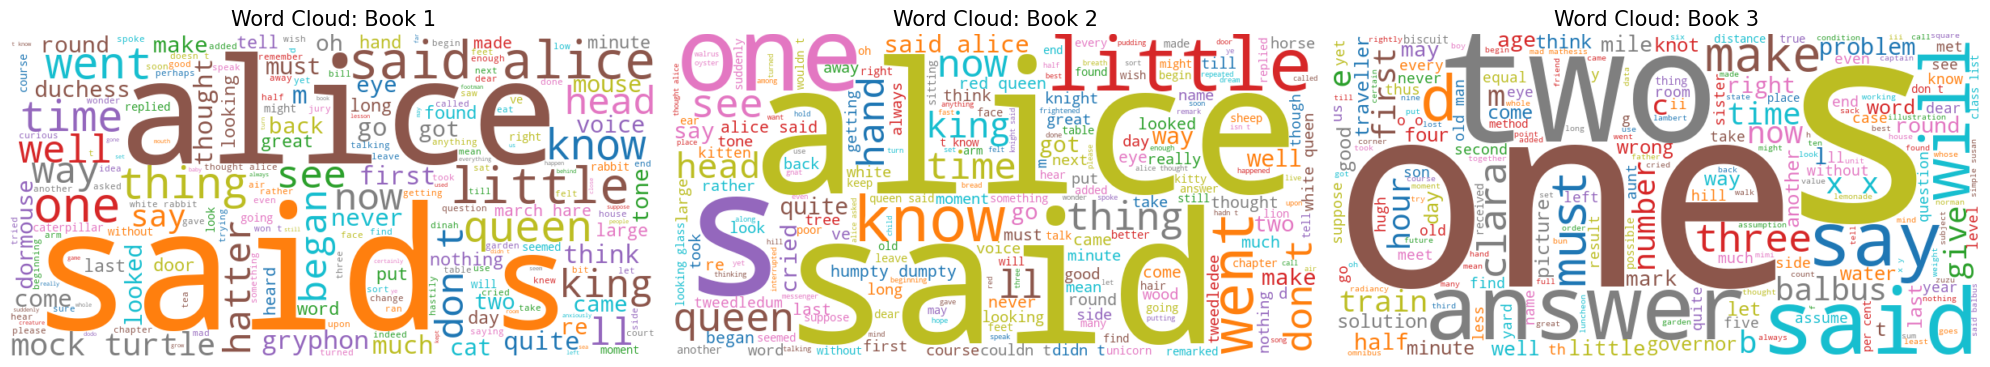

In [33]:
# Analysing the text

# 1. Using wordcloud and matplotlib, display a word cloud of each book.

import matplotlib.pyplot as plt
from wordcloud import WordCloud
# 1. Set up the figure for 3 subplots (1 row, 3 columns)
plt.figure(figsize=(20, 10))

for i, tokens in enumerate(cleaned_corpus_tokens):
    # WordCloud needs a single string, not a list of tokens
    text_string = " ".join(tokens)
    
    # 2. Generate the word cloud
    # You can customize background_color, colormap (e.g., 'viridis', 'magma'), and max_words
    wc = WordCloud(width=800, height=400, background_color='white', colormap='tab10').generate(text_string)
    
    # 3. Add to the subplot
    plt.subplot(1, 3, i + 1)
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f"Word Cloud: Book {i+1}", fontsize=15)
    plt.axis("off") # Hide the x and y axis numbers

# 4. Show the final result
plt.tight_layout()
plt.show()

In [35]:
# 2. Use BoW method to check the five most frequent words in all the books

# hint: What will be the best text from the preprocess step? (raw text, stemmed, lemmarized, etc)?
# This requires raw text, as stemmed and lemmatized texts don't contain the exact words in all the books.

from collections import Counter

# 1. Identify the 5 most frequent words in EACH book
for i, tokens in enumerate(cleaned_corpus_tokens):
    # Use Counter to create a Bag of Words frequency dictionary
    bow = Counter(tokens)
    
    # Get the top 5
    top_five = bow.most_common(5)
    
    print(f"--- Book {i+1} Top 5 Words ---")
    for word, count in top_five:
        print(f"{word}: {count}")
    print("\n")


--- Book 1 Top 5 Words ---
the: 1651
and: 874
to: 729
a: 637
it: 595


--- Book 2 Top 5 Words ---
the: 1609
and: 919
a: 768
to: 756
it: 669


--- Book 3 Top 5 Words ---
the: 1740
and: 790
of: 771
to: 620
a: 619




In [37]:
# To see the top 5 words in all the books combined:

# Flatten the list of lists into one single list of all tokens
all_tokens = [token for book in cleaned_corpus_tokens for token in book]

# Create the total Bag of Words
total_bow = Counter(all_tokens)

print("--- Entire Corpus Top 5 Words ---")
for word, count in total_bow.most_common(5):
    print(f"{word}: {count}")

--- Entire Corpus Top 5 Words ---
the: 5000
and: 2583
to: 2105
a: 2024
of: 1783


In [39]:
# 3. Print the BoW and identify the numbers: What is the document number? What is the index and what is how many times the word was found?

# Here, the document number is the index of the text in the list (0,1,2).
# The word index is the unique integer assigned to every unique word in the entire corpus, usually in alphabetical order.
# 
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import CountVectorizer

# 1. Prepare the text
corpus_strings = [" ".join(tokens) for tokens in cleaned_corpus_tokens]

# 2. Initialize and fit the Vectorizer
vectorizer = CountVectorizer()
bow_matrix = vectorizer.fit_transform(corpus_strings)
feature_names = vectorizer.get_feature_names_out()

# 3. Convert to COO format to easily iterate through rows and columns
bow_sparse = bow_matrix.tocoo()

print(f"{'Doc #':<7} | {'Word Index':<10} | {'Word':<15} | {'Frequency':<10}")
print("-" * 50)

# Track how many words we've printed for each book
counts_per_doc = {0: 0, 1: 0, 2: 0}
limit = 5 # How many words to show per book

for row, col, value in zip(bow_sparse.row, bow_sparse.col, bow_sparse.data):
    if counts_per_doc[row] < limit:
        word = feature_names[col]
        print(f"{row:<7} | {col:<10} | {word:<15} | {value:<10}")
        counts_per_doc[row] += 1

    # Stop once we have reached the limit for all documents
    if all(count >= limit for count in counts_per_doc.values()):
        break

Doc #   | Word Index | Word            | Frequency 
--------------------------------------------------
0       | 139        | alice           | 400       
0       | 85         | adventures      | 8         
0       | 2677       | in              | 371       
0       | 6002       | wonderland      | 4         
0       | 2647       | illustration    | 1         
1       | 139        | alice           | 468       
1       | 85         | adventures      | 1         
1       | 2677       | in              | 413       
1       | 6002       | wonderland      | 1         
1       | 2647       | illustration    | 2         
2       | 139        | alice           | 4         
2       | 85         | adventures      | 1         
2       | 2677       | in              | 430       
2       | 6002       | wonderland      | 1         
2       | 2647       | illustration    | 8         


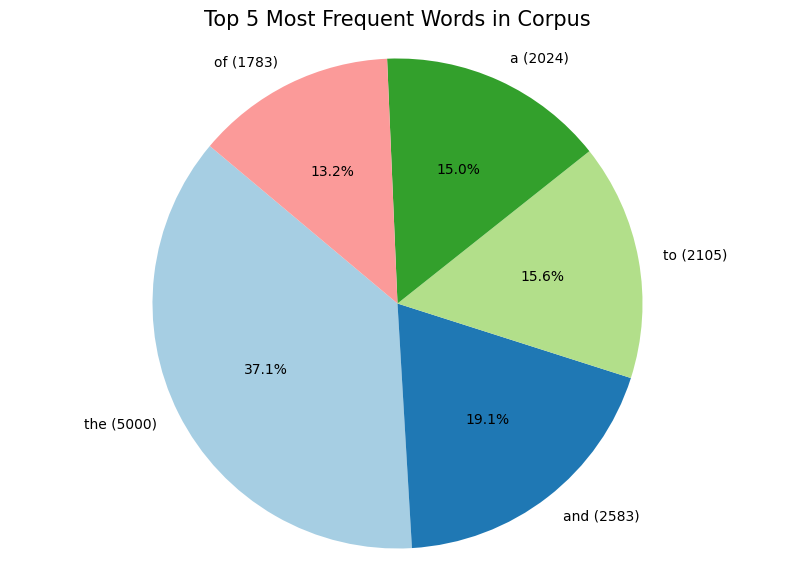

In [40]:
# 4. Display a pie plot of the 5 most frequent words in the text. Add the word and its frequence as labels.

# 1. Combine all tokens from all books into one list
all_tokens = [token for book in cleaned_corpus_tokens for token in book]

# 2. Get the 5 most frequent words
total_bow = Counter(all_tokens)
top_five = total_bow.most_common(5)

# 3. Separate the words (labels) and their counts (values)
# We will format the labels to include the frequency count
labels = [f"{word} ({count})" for word, count in top_five]
values = [count for word, count in top_five]

# 4. Create the Pie Plot
plt.figure(figsize=(10, 7))
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)

plt.title("Top 5 Most Frequent Words in Corpus", fontsize=15)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

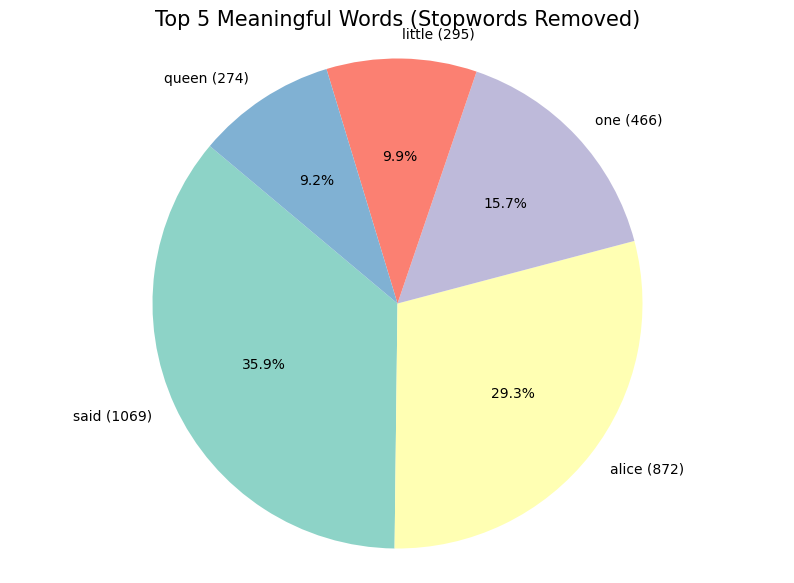

In [41]:
# 5. Analyse the outputs: Are those words informative? Are they insightful or expected? 

# This is certainly expected. These are very common words, among the most common words used in English, and considered
# stopwords. They are not necessarily informative or insightful. We could do this again after removing stopwords to
# attain greater insight. Here we go:

# 1. Load the English stopwords
# Ensure you've run nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# 2. Combine and filter all tokens
# We lowercase them to match the stopword list and remove any non-alphabetic items
all_tokens = [token for book in cleaned_corpus_tokens for token in book]
filtered_tokens = [word.lower() for word in all_tokens if word.lower() not in stop_words and word.isalpha()]

# 3. Get the 5 most frequent meaningful words
total_bow_filtered = Counter(filtered_tokens)
top_five_filtered = total_bow_filtered.most_common(5)

# 4. Separate labels and values
labels = [f"{word} ({count})" for word, count in top_five_filtered]
values = [count for word, count in top_five_filtered]

# 5. Create the Pie Plot
plt.figure(figsize=(10, 7))
# Using 'Set3' or 'Pastel1' colormaps often looks nice for these
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=140, colors=plt.cm.Set3.colors)

plt.title("Top 5 Meaningful Words (Stopwords Removed)", fontsize=15)
plt.axis('equal') 
plt.show()

In [ ]:
# This is a bit more insightful, and shows us two main characters in the texts: queen and alice.

In [42]:
# Solving the frequency problem using TF-IDF

# When we create a BoW out from some text, all the words are treated equaly as importants. Like “Alice” or “say” in a fantasy book about Alice. We expected those words to be repeated all over the book, making them not so informative to us.

# The solution for this problem would be to consider the frequency relative to the corpus. In this case, if there is a word in a document that doesn’t appears much in the other documents, it is likely meaningful and should be considered more important. And the same way in the oposite: A word that is repeated a lot in all the documents will be considered less important.

# That’s the perfect situation to use TF-IDF (Term Frequency-Inverse Document Frequency)

# 1. Create another BoW, now using TF-IDF as vectorizer.

# hint: You need to pass min_df=1, max_df=2 as arguments of the TfidfVectorizer(), because we are using a small dataset.

from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# 1. Convert tokens back to strings for the vectorizer
corpus_strings = [" ".join(tokens) for tokens in cleaned_corpus_tokens]

# 2. Initialize the TfidfVectorizer with your specific constraints
# min_df=1: word must appear in at least 1 document
# max_df=2: word must appear in at most 2 documents (prevents common words across all 3)
tfidf_vectorizer = TfidfVectorizer(min_df=1, max_df=2)

# 3. Fit and transform the corpus
tfidf_matrix = tfidf_vectorizer.fit_transform(corpus_strings)

# 4. Get the feature names (words)
feature_names = tfidf_vectorizer.get_feature_names_out()

# 5. Display the top 5 words per book based on TF-IDF score
print("--- Top 5 Unique Words per Book (TF-IDF) ---")
for i, row in enumerate(tfidf_matrix.toarray()):
    # Get indices of the highest TF-IDF scores for this row
    top_indices = row.argsort()[-5:][::-1]
    
    print(f"\nBook {i+1}:")
    for idx in top_indices:
        print(f"Word: {feature_names[idx]:<15} Score: {row[idx]:.4f}")

--- Top 5 Unique Words per Book (TF-IDF) ---

Book 1:
Word: gryphon         Score: 0.3291
Word: rabbit          Score: 0.3171
Word: turtle          Score: 0.2731
Word: mock            Score: 0.2594
Word: hatter          Score: 0.2549

Book 2:
Word: dumpty          Score: 0.3490
Word: humpty          Score: 0.3490
Word: knight          Score: 0.2796
Word: tweedledum      Score: 0.2306
Word: tweedledee      Score: 0.1807

Book 3:
Word: balbus          Score: 0.3150
Word: clara           Score: 0.2795
Word: problem         Score: 0.1863
Word: marks           Score: 0.1508
Word: governor        Score: 0.1464


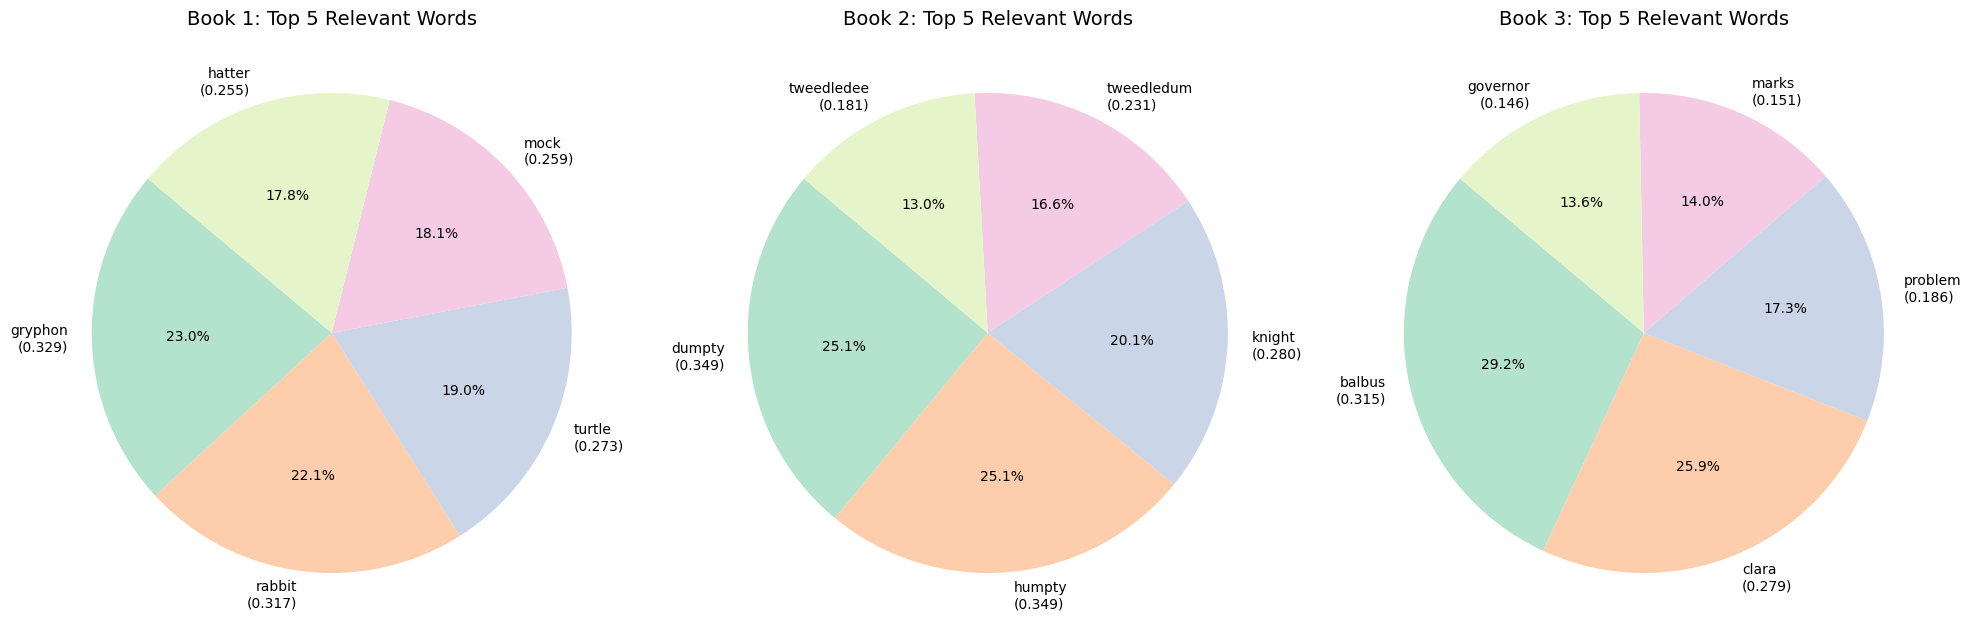

In [43]:
# 2. Create again the pie plots with the new 5 most relevant words from each document.
# Unlike the previous BoW pie chart which showed raw counts, these slices represent the importance (weight) of the word to that specific document.

import matplotlib.pyplot as plt

# 1. Convert TF-IDF matrix to array for easier handling
tfidf_array = tfidf_matrix.toarray()

# 2. Set up the plotting area (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

for i in range(len(corpus_strings)):
    # Get the top 5 indices for this specific book
    # row.argsort() gives indices of scores from lowest to highest
    row = tfidf_array[i]
    top_indices = row.argsort()[-5:][::-1]
    
    # Get the words and their corresponding TF-IDF scores
    labels = [feature_names[idx] for idx in top_indices]
    values = [row[idx] for idx in top_indices]
    
    # Create labels that show both the word and the importance score
    formatted_labels = [f"{word}\n({score:.3f})" for word, score in zip(labels, values)]
    
    # Plotting
    axes[i].pie(values, labels=formatted_labels, autopct='%1.1f%%', 
                startangle=140, colors=plt.cm.Pastel2.colors)
    axes[i].set_title(f"Book {i+1}: Top 5 Relevant Words", fontsize=14)

plt.tight_layout()
plt.show()
